<h1 style="color:magenta;">NSL - Exercises 11 </h1>

### 21/5/2026
### Giulia Federica Bianca Coppi (84486A)

## Ex 11.1

### Linear fit

The aim of this exercise is to predict the following linear function trough a neural netrwork regression:

$$
f(x)=2x+1
$$

Moreover, we want to find the best parameters $(\sigma_{noise}, N_{epochs}, N_{train})$ for the regression.

At the end of the notebook can be found the loss function obtained by varying those parameters. The best fit was found to be
- $\sigma = 0.1-0.2$ (we don't want our training data to be too dispersed)
- $N_{epochs}=25-35$, fewer epochs would result in underfitting, while more epochs would not improve the performance, leading only to an unnecessary computational cost as the loss reaches a plateau. If the function wasn't linear we would incur in overfitting
- $N_{train}= 800-1000$

In [23]:
# target parameters of f(x) = m*x + b
m = 2 # slope
b = 1 # intersect

In [24]:
import numpy as np

# generate training inputs
np.random.seed(0)
x_train = np.random.uniform(-1, 1, 1000)   #Qua ha messo il numero di N train
x_valid = np.random.uniform(-1, 1, 50)
x_valid.sort()
y_target = m * x_valid + b # ideal (target) linear function

sigma = 0.1 # noise standard deviation, for the moment it is absent
y_train = np.random.normal(m * x_train + b, sigma) # actual measures from which we want to guess regression parameters
y_valid = np.random.normal(m * x_valid + b, sigma)

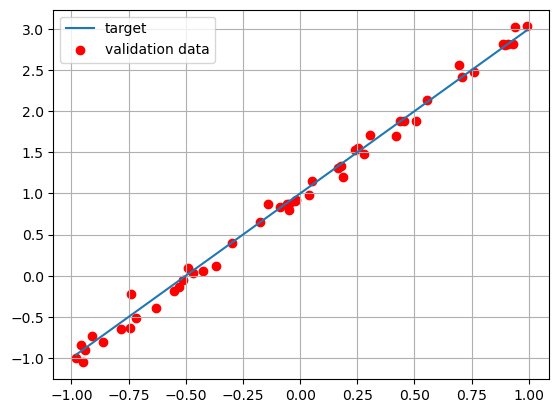

In [25]:
# plot validation and target dataset
import matplotlib.pyplot as plt
plt.plot(x_valid, y_target, label='target')
plt.scatter(x_valid, y_valid, color='r', label='validation data')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# compose the NN model
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

model = tf.keras.Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(1))

# compile the model choosing optimizer, loss and metrics objects
model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

In [27]:
# get a summary of our composed model
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
# fit the model using training dataset
# over 10 epochs of 32 batch size each
# report training progress against validation data
history = model.fit(x=x_train, y=y_train, 
          batch_size=32, epochs=100,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          validation_data=(x_valid, y_valid))

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9621 - mse: 0.9621 - val_loss: 0.5720 - val_mse: 0.5720
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4126 - mse: 0.4126 - val_loss: 0.2846 - val_mse: 0.2846
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2124 - mse: 0.2124 - val_loss: 0.1681 - val_mse: 0.1681
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1263 - mse: 0.1263 - val_loss: 0.1081 - val_mse: 0.1081
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0808 - mse: 0.0808 - val_loss: 0.0735 - val_mse: 0.0735
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0546 - mse: 0.0546 - val_loss: 0.0515 - val_mse: 0.0515
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0380 - mse: 0.0380 - val_loss: 0.0376 - val_mse: 0.0376
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0279 - mse: 0.0279 - val_loss: 0.0283 - val_mse: 0.0283
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.021

By looking at weights and biases we can see if the linear fit was successfull: $w_1$ represents the angular coefficient, $b$ the intercept.

In [29]:
# return weights and biases
model.get_weights()

[array([[1.9955289]], dtype=float32), array([1.0029241], dtype=float32)]

In [30]:
# evaluate model
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0084 - mse: 0.0084

Test loss: 0.008422927930951118
Test accuracy: 0.008422927930951118


In [31]:
# evaluate model with the exact curve
score = model.evaluate(x_valid, y_target, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.6579e-05 - mse: 1.6579e-05

Test loss: 1.6579468137933873e-05
Test accuracy: 1.6579468137933873e-05


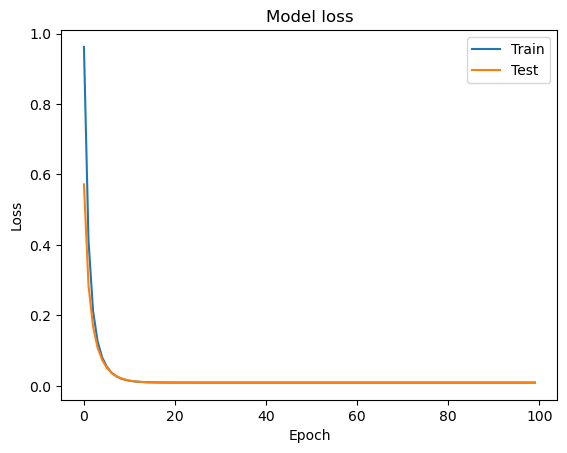

In [32]:
# look into training history
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


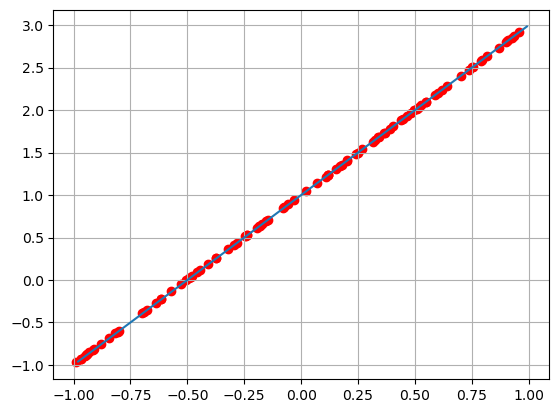

In [33]:
x_predicted = np.random.uniform(-1, 1, 100)
y_predicted = model.predict(x_predicted)
plt.scatter(x_predicted, y_predicted,color='r')
plt.plot(x_valid, y_target)
plt.grid(True)
plt.show()

In [112]:
#Print Epochs, Loss and training loss for each sigma changed
import numpy as np

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = np.arange(1, len(loss) + 1)

# Uniamo i vettori in una matrice dove ogni colonna è una variabile
# np.c_ unisce gli array per colonna (colonna 1: epoche, colonna 2: loss, colonna 3: val_loss)
data = np.c_[epochs, loss, val_loss]

np.savetxt(
    "risultati_training_sigma_06.data", 
    data, 
    fmt=["%d", "%.6f", "%.6f"],       # Formato: intero per le epoche, float a 6 decimali per le loss
    delimiter="\t",                    # Separatore di colonna (tabulazione)
    header="Epoch\tLoss\tVal_Loss",    # Intestazione automatica (inserisce già il '#' all'inizio)
    comments="# "
)

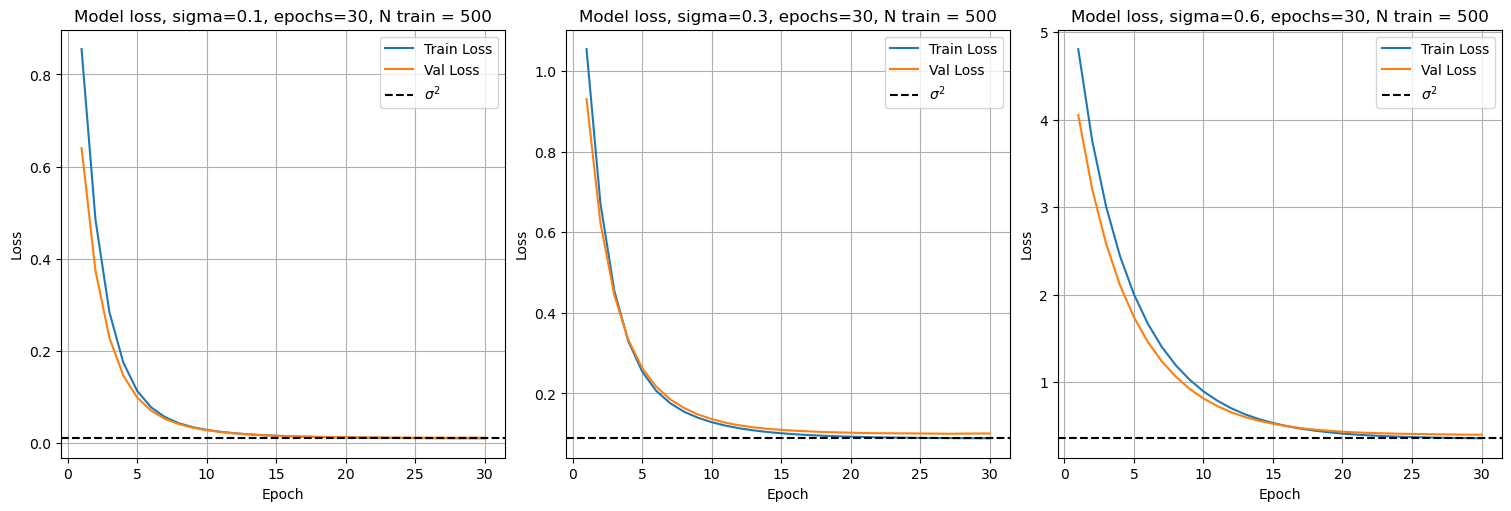

In [1]:
import matplotlib.pyplot as plt
import numpy as np

data_1 = np.loadtxt("risultati_training_sigma_01.data")
data_2 = np.loadtxt("risultati_training_sigma_03.data")
data_3 = np.loadtxt("risultati_training_sigma_06.data")

epoche_1 = data_1[:, 0]
t_loss_1 = data_1[:, 1]
v_loss_1 = data_1[:, 2]

epoche_2 = data_2[:, 0]
t_loss_2 = data_2[:, 1]
v_loss_2 = data_2[:, 2]

epoche_3 = data_3[:, 0]
t_loss_3 = data_3[:, 1]
v_loss_3 = data_3[:, 2]

fig, ax = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

ax[0].plot(epoche_1, t_loss_1, label="Train Loss")
ax[0].plot(epoche_1, v_loss_1, label="Val Loss")
ax[0].set_title("Model loss, sigma=0.1, epochs=30, N train = 500")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].axhline(0.01, color='black', linestyle='--', linewidth=1.5, label="$\sigma^2$")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(epoche_2, t_loss_2, label="Train Loss")
ax[1].plot(epoche_2, v_loss_2, label="Val Loss")
ax[1].set_title("Model loss, sigma=0.3, epochs=30, N train = 500")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].axhline(0.09, color='black', linestyle='--', linewidth=1.5, label="$\sigma^2$")
ax[1].legend()
ax[1].grid(True)

ax[2].plot(epoche_3, t_loss_3, label="Train Loss")
ax[2].plot(epoche_3, v_loss_3, label="Val Loss")
ax[2].set_title("Model loss, sigma=0.6, epochs=30, N train = 500")
ax[2].set_xlabel("Epoch")
ax[2].set_ylabel("Loss")
ax[2].axhline(0.36, color='black', linestyle='--', linewidth=1.5, label="$\sigma^2$")
ax[2].legend()
ax[2].grid(True)

plt.show()

In [63]:
#Print Epochs, Loss and training loss for each sigma changed

#sigma = 0.1, change the number of epochs
import numpy as np

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = np.arange(1, len(loss) + 1)

# Uniamo i vettori in una matrice dove ogni colonna è una variabile
# np.c_ unisce gli array per colonna (colonna 1: epoche, colonna 2: loss, colonna 3: val_loss)
data = np.c_[epochs, loss, val_loss]

np.savetxt(
    "risultati_training_epochs_50.data", 
    data, 
    fmt=["%d", "%.6f", "%.6f"],       # Formato: intero per le epoche, float a 6 decimali per le loss
    delimiter="\t",                    # Separatore di colonna (tabulazione)
    header="Epoch\tLoss\tVal_Loss",    # Intestazione automatica (inserisce già il '#' all'inizio)
    comments="# "
)

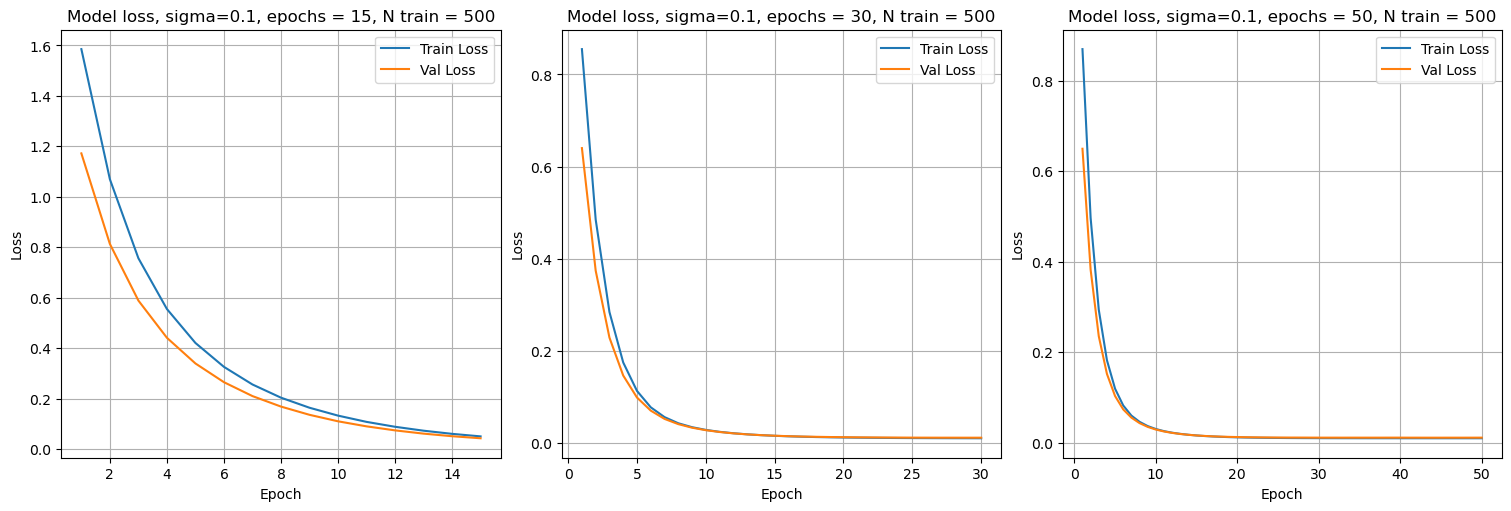

In [22]:
import matplotlib.pyplot as plt
import numpy as np

data_1 = np.loadtxt("risultati_training_epochs_15.data")
data_2 = np.loadtxt("risultati_training_epochs_30.data")
data_3 = np.loadtxt("risultati_training_epochs_50.data")

epoche_1 = data_1[:, 0]
t_loss_1 = data_1[:, 1]
v_loss_1 = data_1[:, 2]

epoche_2 = data_2[:, 0]
t_loss_2 = data_2[:, 1]
v_loss_2 = data_2[:, 2]

epoche_3 = data_3[:, 0]
t_loss_3 = data_3[:, 1]
v_loss_3 = data_3[:, 2]

fig, ax = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

ax[0].plot(epoche_1, t_loss_1, label="Train Loss")
ax[0].plot(epoche_1, v_loss_1, label="Val Loss")
ax[0].set_title("Model loss, sigma=0.1, epochs = 15, N train = 500")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(epoche_2, t_loss_2, label="Train Loss")
ax[1].plot(epoche_2, v_loss_2, label="Val Loss")
ax[1].set_title("Model loss, sigma=0.1, epochs = 30, N train = 500")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].legend()
ax[1].grid(True)

ax[2].plot(epoche_3, t_loss_3, label="Train Loss")
ax[2].plot(epoche_3, v_loss_3, label="Val Loss")
ax[2].set_title("Model loss, sigma=0.1, epochs = 50, N train = 500")
ax[2].set_xlabel("Epoch")
ax[2].set_ylabel("Loss")
ax[2].legend()
ax[2].grid(True)

plt.show()

In [98]:
#Print Epochs, Loss and training loss for each sigma changed

#sigma = 0.1, epochs=25, change N train
import numpy as np

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = np.arange(1, len(loss) + 1)

# Uniamo i vettori in una matrice dove ogni colonna è una variabile
# np.c_ unisce gli array per colonna (colonna 1: epoche, colonna 2: loss, colonna 3: val_loss)
data = np.c_[epochs, loss, val_loss]

np.savetxt(
    "risultati_training_Ntrain_800.data", 
    data, 
    fmt=["%d", "%.6f", "%.6f"],       # Formato: intero per le epoche, float a 6 decimali per le loss
    delimiter="\t",                    # Separatore di colonna (tabulazione)
    header="Epoch\tLoss\tVal_Loss",    # Intestazione automatica (inserisce già il '#' all'inizio)
    comments="# "
)

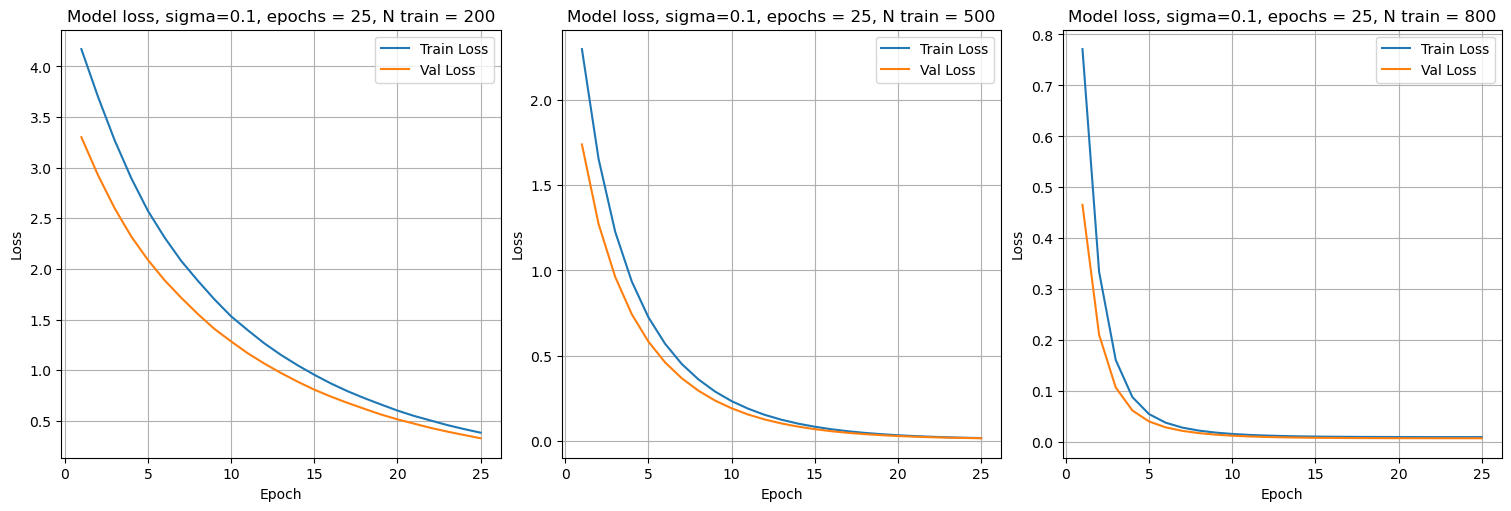

In [99]:
import matplotlib.pyplot as plt
import numpy as np

data_1 = np.loadtxt("risultati_training_Ntrain_200.data")
data_2 = np.loadtxt("risultati_training_Ntrain_500.data")
data_3 = np.loadtxt("risultati_training_Ntrain_800.data")

epoche_1 = data_1[:, 0]
t_loss_1 = data_1[:, 1]
v_loss_1 = data_1[:, 2]

epoche_2 = data_2[:, 0]
t_loss_2 = data_2[:, 1]
v_loss_2 = data_2[:, 2]

epoche_3 = data_3[:, 0]
t_loss_3 = data_3[:, 1]
v_loss_3 = data_3[:, 2]

fig, ax = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

ax[0].plot(epoche_1, t_loss_1, label="Train Loss")
ax[0].plot(epoche_1, v_loss_1, label="Val Loss")
ax[0].set_title("Model loss, sigma=0.1, epochs = 25, N train = 200")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(epoche_2, t_loss_2, label="Train Loss")
ax[1].plot(epoche_2, v_loss_2, label="Val Loss")
ax[1].set_title("Model loss, sigma=0.1, epochs = 25, N train = 500")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].legend()
ax[1].grid(True)

ax[2].plot(epoche_3, t_loss_3, label="Train Loss")
ax[2].plot(epoche_3, v_loss_3, label="Val Loss")
ax[2].set_title("Model loss, sigma=0.1, epochs = 25, N train = 800")
ax[2].set_xlabel("Epoch")
ax[2].set_ylabel("Loss")
ax[2].legend()
ax[2].grid(True)

plt.show()